# System tools to herd the dumps into something useful

In [1]:
%pylab widget

import os
import re

# from topas2numpy import read_ntuple
from datetime import datetime
from pylab import figure, cm
from matplotlib.colors import LogNorm

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


## Making a new analysis directory

In [2]:
now = datetime.now()

dt_string = now.strftime("%Y-%m-%d-h%Hm%M")

print(dt_string)

os.mkdir(f'analysis/{dt_string}')

2024-12-18-h11m21


## Reformat the dump

In [3]:
%%bash

for dir in */; do
  cd "$dir"
  
  rename -e 's/\d+/sprintf("%04d",$&)/e' -- *.csv
  ls *.csv | grep -o '[0-9][0-9]*' > energies.txt
  cat *.csv | awk 'NR % 6 == 0' > deposition.txt
  rename -e 's/\d+/sprintf("%04d",$&)/e' -- *.phsp
  rename -e 's/\d+/sprintf("%04d",$&)/e' -- *.header
  
  cd ..
done

ls: cannot access '*.csv': No such file or directory
cat: '*.csv': No such file or directory


In [4]:
#!cat energies.txt deposition.txt
#!cat deposition.txt

In [5]:
import os
import numpy as np
import pandas as pd

data = []

for subdir, _, _ in os.walk('.'):
    energies_path = os.path.join(subdir, 'energies.txt')
    deposition_path = os.path.join(subdir, 'deposition.txt')
    
    if os.path.exists(energies_path) and os.path.exists(deposition_path):
        with open(energies_path) as f:
            energies = np.array([[x for x in line.split()] for line in f]).astype(float).flatten()
        
        with open(deposition_path) as f:
            array = np.array([[x for x in line.split()] for line in f]).flatten()
            deposition = array.astype(float)
        
        for e, d in zip(energies, deposition):
            data.append({'Subdirectory': subdir, 'Energy': e, 'Deposition': d})

df = pd.DataFrame(data)
print(df)

     Subdirectory  Energy     Deposition
0    ./0.5mm_SnBU    10.0       0.000000
1    ./0.5mm_SnBU    20.0       5.380952
2    ./0.5mm_SnBU    30.0      58.064137
3    ./0.5mm_SnBU    40.0     146.332764
4    ./0.5mm_SnBU    50.0    1142.515625
..            ...     ...            ...
319    ./1mm_TiBU   900.0  178299.328125
320    ./1mm_TiBU  1000.0  193338.828125
321    ./1mm_TiBU  2000.0  318359.187500
322    ./1mm_TiBU  4000.0  529402.312500
323    ./1mm_TiBU  6000.0  717565.625000

[324 rows x 3 columns]


In [11]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import gecco

# Specify the directory whose contents you want to copy
additional_dir = '/home/jericho/Software/gecco/gecco/data/Detectors/CuGOS-784-micrometer'

data = []

for subdir, _, _ in os.walk('.'):
    energies_path = os.path.join(subdir, 'energies.txt')
    deposition_path = os.path.join(subdir, 'deposition.txt')
    
    if os.path.exists(energies_path) and os.path.exists(deposition_path):
        with open(energies_path) as f:
            energies = np.array([[x for x in line.split()] for line in f]).astype(float).flatten()
        
        with open(deposition_path) as f:
            array = np.array([[x for x in line.split()] for line in f]).flatten()
            deposition = array.astype(float)
        
        for e, d in zip(energies, deposition):
            data.append({'Subdirectory': subdir, 'Energy': e, 'Deposition': d})

        # # In each subdirectory make a npy file containing the energy and deposition
        # np.save(f'{subdir}/EnergyDeposition.npy', np.array([deposition, energies]))

        # Create a new subdirectory by appending "-784-micrometer" to the end of the directory name
        new_subdir = f'{subdir}-784-micrometer'
        os.makedirs(new_subdir, exist_ok=True)



        # Copy the contents of the additional directory to the new subdirectory
        for item in os.listdir(additional_dir):
            s = os.path.join(additional_dir, item)
            d = os.path.join(new_subdir, item)
            if os.path.isdir(s):
                shutil.copytree(s, d, dirs_exist_ok=True)
            else:
                shutil.copy2(s, d)
        # Copy the EnergyDeposition.npy file to the new subdirectory
        shutil.copy(f'{subdir}/EnergyDeposition.npy', new_subdir)

df = pd.DataFrame(data)


# Water

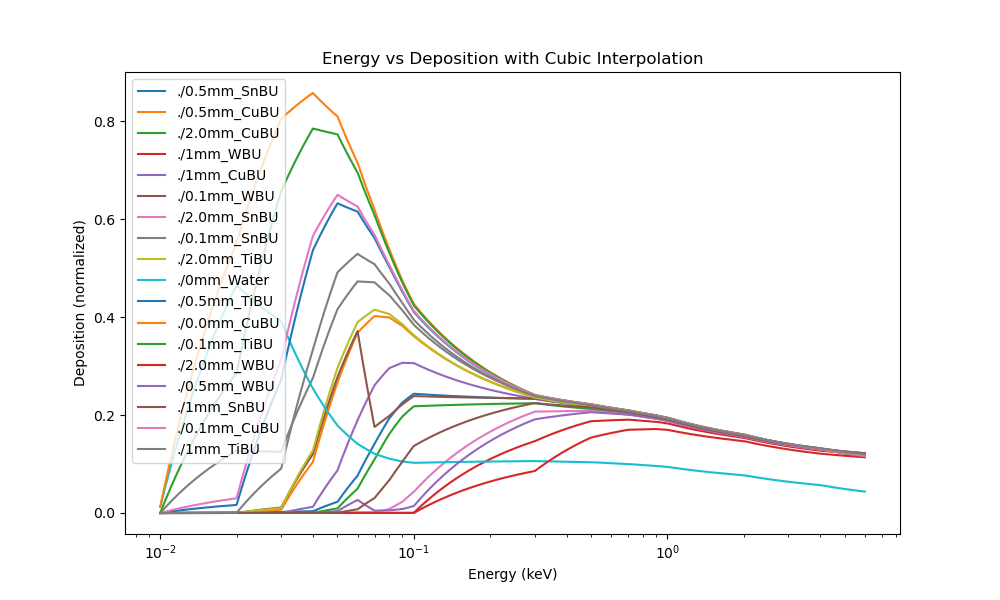

In [12]:

# Plotting
plt.figure(figsize=(10, 6))
spectrum_energies = np.logspace(np.log10(10), np.log10(6000), 2000)
# spectrum_energies = np.linspace(10, 6000, 1000)

for subdir in df['Subdirectory'].unique():
    subdir_data = df[df['Subdirectory'] == subdir]
    energies = subdir_data['Energy'].values
    deposition = subdir_data['Deposition'].values
    
    # Perform cubic interpolation
    cubic_interp = interp1d(energies, deposition, kind='linear', fill_value="extrapolate")
    interpolated_deposition = cubic_interp(spectrum_energies)
    interpolated_deposition[interpolated_deposition < 0] = 0
    plt.semilogx(spectrum_energies / 1000, interpolated_deposition / (spectrum_energies / 1000) / 1000000, label=subdir)
    # plt.semilogx(energies / 1000, deposition / (energies / 1000) / 1000000, label=subdir)

plt.xlabel('Energy (keV)')
plt.ylabel('Deposition (normalized)')
plt.title('Energy vs Deposition with Cubic Interpolation')
plt.legend()
plt.show()

In [14]:
gecco.list_spectra_files()


AVAILABLE Saved SPECTRA (for fc.Spectrum.load('SPECTRA'):
Can also use an analytical spectra

Al_spectrum_25
Al_spectrum_6
C_spectrum_25
C_spectrum_6
Varian_truebeam
Varian_truebeam_phasespace
W_spectrum_25
W_spectrum_6
spectrum_120kVp_2mmAl


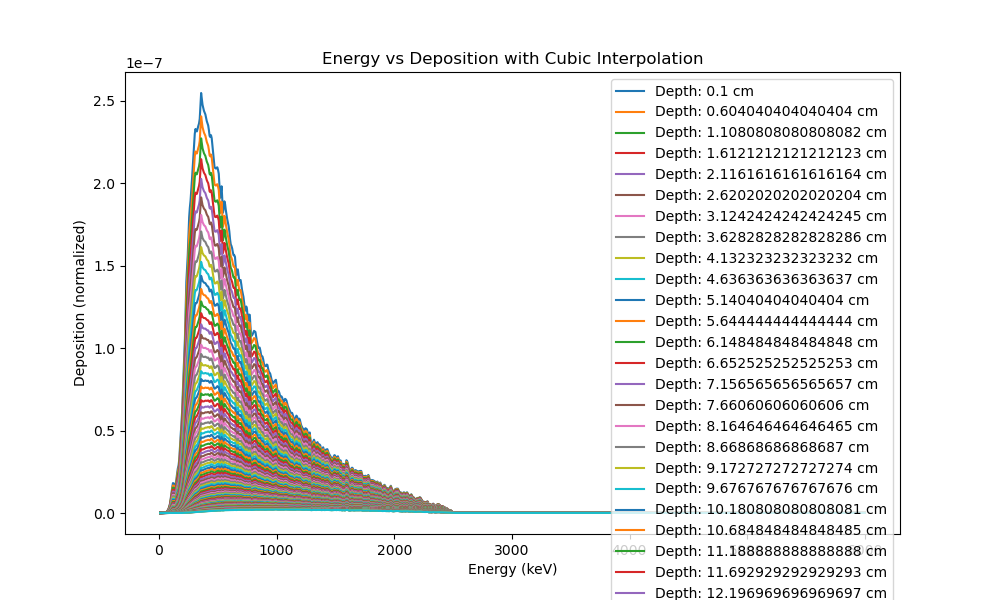

In [57]:

# Plotting
plt.figure(figsize=(10, 6))
spectrum_energies = np.linspace(10, 6000, 1000)

depths = np.linspace(0.1, 50, 100)

total_energies = []
for depth in depths:
    mv_truebeam = gecco.Spectrum()
    mv_truebeam.load('W_spectrum_25')
    mv_truebeam.y = np.abs(mv_truebeam.y[2:])
    mv_truebeam.x = np.abs(mv_truebeam.x[2:])
    mv_truebeam.attenuate(depth,mu = gecco.get_mu('water'))
    xx_tb, yy_tb = mv_truebeam.x, mv_truebeam.y
    yy_tb_long = np.interp(spectrum_energies, xx_tb, yy_tb)
    plt.plot(spectrum_energies, yy_tb_long, label=f'Depth: {depth} cm')
    for subdir in df['Subdirectory'].unique():
        subdir_data = df[df['Subdirectory'] == subdir]
        energies = subdir_data['Energy'].values
        deposition = subdir_data['Deposition'].values
        
        # Perform cubic interpolation
        cubic_interp = interp1d(energies, deposition, kind='linear', fill_value="extrapolate")
        interpolated_deposition = cubic_interp(spectrum_energies)
        interpolated_deposition[interpolated_deposition < 0] = 0
        # plt.semilogx(spectrum_energies / 1000, interpolated_deposition / (spectrum_energies / 1000) / 1000000, label=subdir)

        total_energies.append((yy_tb_long * (spectrum_energies / 1000) * (interpolated_deposition / (spectrum_energies / 1000) / 1000000)).sum())
        # plt.semilogx(energies / 1000, deposition / (energies / 1000) / 1000000, label=subdir)

plt.xlabel('Energy (keV)')
plt.ylabel('Deposition (normalized)')
plt.title('Energy vs Deposition with Cubic Interpolation')
plt.legend()
plt.show()

In [58]:
total_energies = np.array(total_energies).reshape(len(depths), len(df['Subdirectory'].unique()))

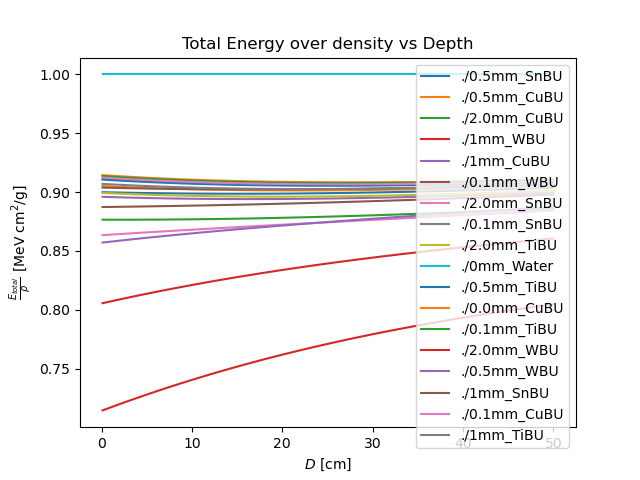

In [59]:
plt.figure()
for ii in range(total_energies.shape[1]):
    if ii == 9:
        plt.plot(depths, total_energies[:,ii]/total_energies[:,9], label=df['Subdirectory'].unique()[ii])
    else:
        plt.plot(depths, total_energies[:,ii]/total_energies[:,9]/2.33, label=df['Subdirectory'].unique()[ii])
# plt.plot(depths, total_energies)
plt.xlabel('$D$ [cm]')
plt.ylabel(r"$\frac{E_{total}}{\rho}$ [MeV cm$^2$/g]")
plt.title('Total Energy over density vs Depth')
plt.legend(df['Subdirectory'].unique())

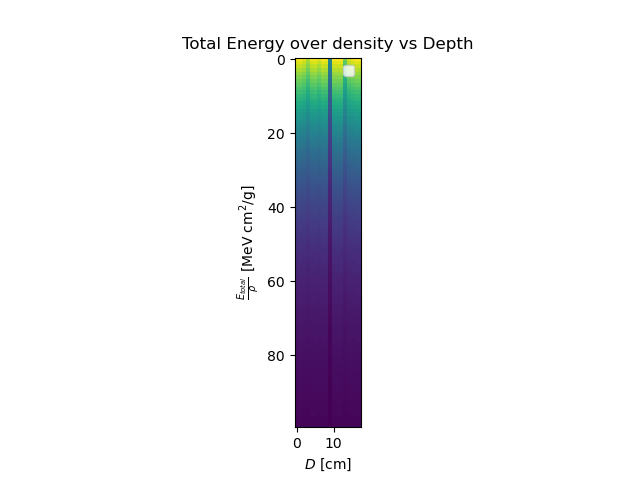

In [71]:
plt.figure()
for ii in range(total_energies.shape[1]):
    plt.imshow(total_energies/2.33, label=df['Subdirectory'].unique()[ii])
# plt.plot(depths, total_energies)
plt.xlabel('$D$ [cm]')
plt.ylabel(r"$\frac{E_{total}}{\rho}$ [MeV cm$^2$/g]")
plt.title('Total Energy over density vs Depth')
plt.legend(df['Subdirectory'].unique())

Top 5 most linear curves based on R-squared values:
./0mm_Water: R-squared = -0.0000
./0.1mm_WBU: R-squared = -0.0012
./0.5mm_CuBU: R-squared = -0.0012
./1mm_TiBU: R-squared = -0.0013
./0.5mm_TiBU: R-squared = -0.0013


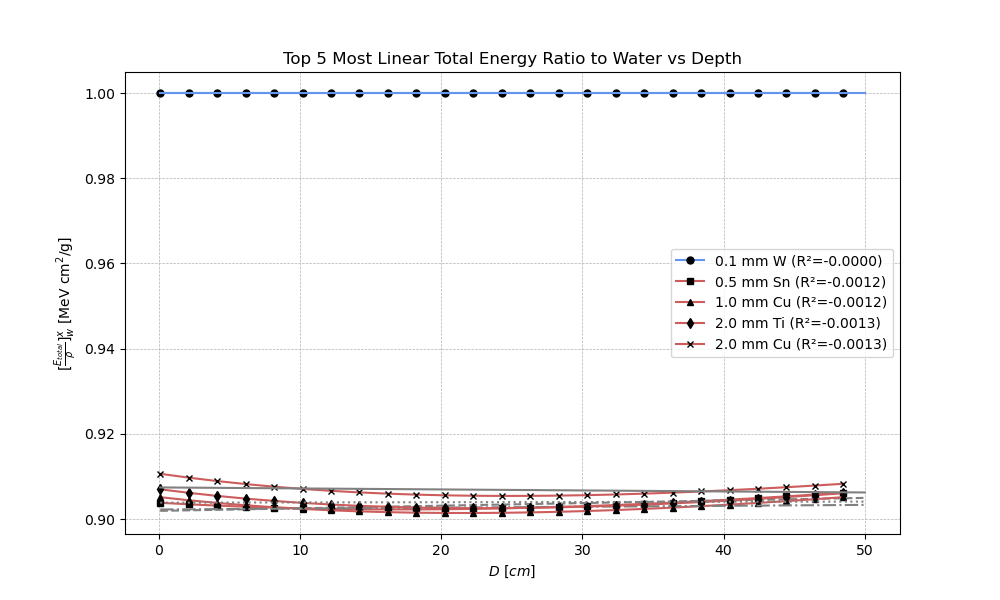

In [65]:
r_squared_values = []

for ii in range(total_energies.shape[1]):
    if ii == 9:
        y = total_energies[:, ii] / total_energies[:, 9]
    else:
        y = total_energies[:, ii] / total_energies[:, 9] / 2.33
    
    # Perform linear fit
    p = np.polyfit(depths, y, 1)
    y_fit = np.polyval(p, depths)
    
    # Calculate R-squared value
    r_squared = -np.std(y)
    r_squared_values.append((df['Subdirectory'].unique()[ii], r_squared, depths, y, y_fit))

# Sort by R-squared value to find the most linear curves
r_squared_values.sort(key=lambda x: x[1], reverse=True)

# Define line styles and markers for classic black and white plots
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'd', 'x']
labels = ['0.1 mm W',
          '0.5 mm Sn',
          '1.0 mm Cu',
          '2.0 mm Ti',
          '2.0 mm Cu']

# Plot only the top 5 most linear curves
plt.figure(figsize=(10, 6))
for i, (subdir, r_squared, depths, y, y_fit) in enumerate(r_squared_values[:5]):
    if i == 0:
        plt.plot(depths[::4], y[::4], label=f'{labels[i]} (R²={r_squared:.4f})', marker=markers[i % len(markers)], color='cornflowerblue', markersize=5,markerfacecolor='k',markeredgecolor='k')
        plt.plot(depths, y_fit, linestyle=line_styles[i % len(line_styles)], color='cornflowerblue')
    else:
        plt.plot(depths[::4], y[::4], label=f'{labels[i]} (R²={r_squared:.4f})', marker=markers[i % len(markers)], color='indianred', markersize=5,markerfacecolor='k',markeredgecolor='k')
        plt.plot(depths, y_fit, linestyle=line_styles[i % len(line_styles)], color='gray')

plt.xlabel('$D$ $[cm]$')
plt.ylabel(r"$[\frac{E_{total}}{\rho}]_w^x$ [MeV cm$^2$/g]")
plt.title('Top 5 Most Linear Total Energy Ratio to Water vs Depth')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# plt.show()

# Print the top 5 most linear curves
print("Top 5 most linear curves based on R-squared values:")
for subdir, r_squared, _, _, _ in r_squared_values[:5]:
    print(f"{subdir}: R-squared = {r_squared:.4f}")

Top 5 most linear curves based on R-squared values:
./0mm_Water: R-squared = -0.0000
./0.1mm_WBU: R-squared = -0.0012
./0.5mm_CuBU: R-squared = -0.0012
./1mm_TiBU: R-squared = -0.0013
./0.5mm_TiBU: R-squared = -0.0013


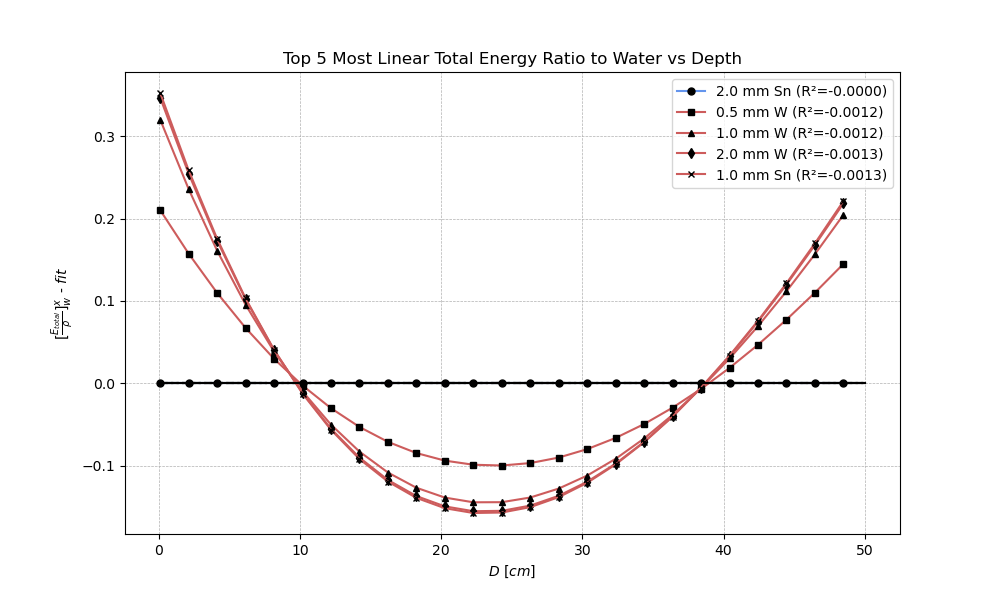

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Assuming total_energies and depths are already defined
# total_energies = ...
# depths = ...

# plt.figure()
r_squared_values = []

for ii in range(total_energies.shape[1]):
    if ii == 9:
        y = total_energies[:, ii] / total_energies[:, 9]
    else:
        y = total_energies[:, ii] / total_energies[:, 9] / 2.33
    
    # Perform linear fit
    p = np.polyfit(depths, y, 1)
    y_fit = np.polyval(p, depths)
    
    # Calculate R-squared value
    r_squared = -y.std()
    r_squared_values.append((df['Subdirectory'].unique()[ii], r_squared, depths, y, y_fit))

# Sort by R-squared value to find the most linear curves
r_squared_values.sort(key=lambda x: x[1], reverse=True)

# Define line styles and markers for classic black and white plots
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'd', 'x']
labels = ['2.0 mm Sn',
          '0.5 mm W',
        '1.0 mm W',
        '2.0 mm W',
        '1.0 mm Sn']

# ./2.0mm_SnBU: R-squared = 0.9993
# ./0.5mm_WBU: R-squared = 0.9934
# ./1mm_WBU: R-squared = 0.9852
# ./2.0mm_WBU: R-squared = 0.9821
# ./1mm_SnBU: R-squared = 0.9805
# Plot only the top 5 most linear curves
plt.figure(figsize=(10, 6))
for i, (subdir, r_squared, depths, y, y_fit) in enumerate(r_squared_values[:5]):
    if i == 0:
        plt.plot(depths[::4], 100*(y[::4] - y_fit[::4])/y_fit[::4], label=f'{labels[i]} (R²={r_squared:.4f})', marker=markers[i % len(markers)], color='cornflowerblue', markersize=5,markerfacecolor='k',markeredgecolor='k')
        plt.plot(depths, y_fit - y_fit, linestyle=line_styles[i % len(line_styles)], color='black')
    else:
        plt.plot(depths[::4], 100*(y[::4] - y_fit[::4])/y_fit[::4], label=f'{labels[i]} (R²={r_squared:.4f})', marker=markers[i % len(markers)], color='indianred', markersize=5,markerfacecolor='k',markeredgecolor='k')
        plt.plot(depths, y_fit - y_fit, linestyle=line_styles[i % len(line_styles)], color='black')

plt.xlabel('$D$ $[cm]$')
plt.ylabel(r"$[\frac{E_{total}}{\rho}]_w^x$ - $fit$")
plt.title('Top 5 Most Linear Total Energy Ratio to Water vs Depth')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# plt.show()

# Print the top 5 most linear curves
print("Top 5 most linear curves based on R-squared values:")
for i, (subdir, r_squared, _, _, _) in enumerate(r_squared_values[:5]):
    print(f"{subdir}: R-squared = {r_squared:.4f}")
plt.legend()


# Bone

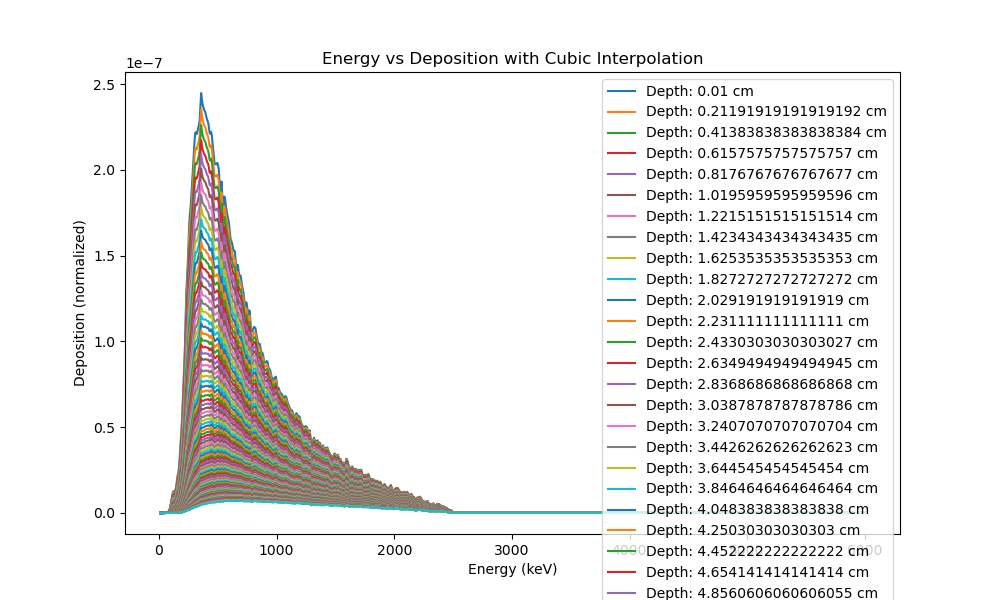

In [40]:

# Plotting
plt.figure(figsize=(10, 6))
spectrum_energies = np.linspace(10, 6000, 1000)

depths = np.linspace(0.01, 20, 100)

total_energies = []
for depth in depths:
    mv_truebeam = gecco.Spectrum()
    mv_truebeam.load('W_spectrum_25')
    mv_truebeam.y = np.abs(mv_truebeam.y[2:])
    mv_truebeam.x = np.abs(mv_truebeam.x[2:])
    mv_truebeam.attenuate(depth,mu = gecco.get_mu('G4_BONE_COMPACT_ICRU'))
    mv_truebeam.attenuate(0.05,mu = gecco.get_mu('50'))
    xx_tb, yy_tb = mv_truebeam.x, mv_truebeam.y
    yy_tb_long = np.interp(spectrum_energies, xx_tb, yy_tb)
    plt.plot(spectrum_energies, yy_tb_long, label=f'Depth: {depth} cm')
    for subdir in df['Subdirectory'].unique():
        subdir_data = df[df['Subdirectory'] == subdir]
        energies = subdir_data['Energy'].values
        deposition = subdir_data['Deposition'].values
        
        # Perform cubic interpolation
        cubic_interp = interp1d(energies, deposition, kind='linear', fill_value="extrapolate")
        interpolated_deposition = cubic_interp(spectrum_energies)
        interpolated_deposition[interpolated_deposition < 0] = 0
        # plt.semilogx(spectrum_energies / 1000, interpolated_deposition / (spectrum_energies / 1000) / 1000000, label=subdir)

        total_energies.append((yy_tb_long * (spectrum_energies / 1000) * (interpolated_deposition / (spectrum_energies / 1000) / 1000000)).sum())
        # plt.semilogx(energies / 1000, deposition / (energies / 1000) / 1000000, label=subdir)

plt.xlabel('Energy (keV)')
plt.ylabel('Deposition (normalized)')
plt.title('Energy vs Deposition with Cubic Interpolation')
plt.legend()
plt.show()

In [41]:
total_energies = np.array(total_energies).reshape(len(depths), len(df['Subdirectory'].unique()))

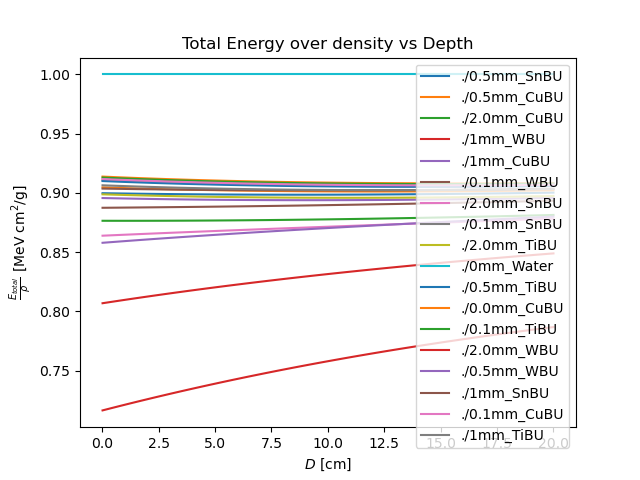

In [42]:
plt.figure()
for ii in range(total_energies.shape[1]):
    if ii == 9:
        plt.plot(depths, total_energies[:,ii]/total_energies[:,9], label=df['Subdirectory'].unique()[ii])
    else:
        plt.plot(depths, total_energies[:,ii]/total_energies[:,9]/2.33, label=df['Subdirectory'].unique()[ii])
# plt.plot(depths, total_energies)
plt.xlabel('$D$ [cm]')
plt.ylabel(r"$\frac{E_{total}}{\rho}$ [MeV cm$^2$/g]")
plt.title('Total Energy over density vs Depth')
plt.legend(df['Subdirectory'].unique())

Top 5 most linear curves based on R-squared values:
./0mm_Water: R-squared = -0.0000
./0.1mm_WBU: R-squared = -0.0004
./0.5mm_SnBU: R-squared = -0.0005
./1mm_CuBU: R-squared = -0.0006
./2.0mm_TiBU: R-squared = -0.0008


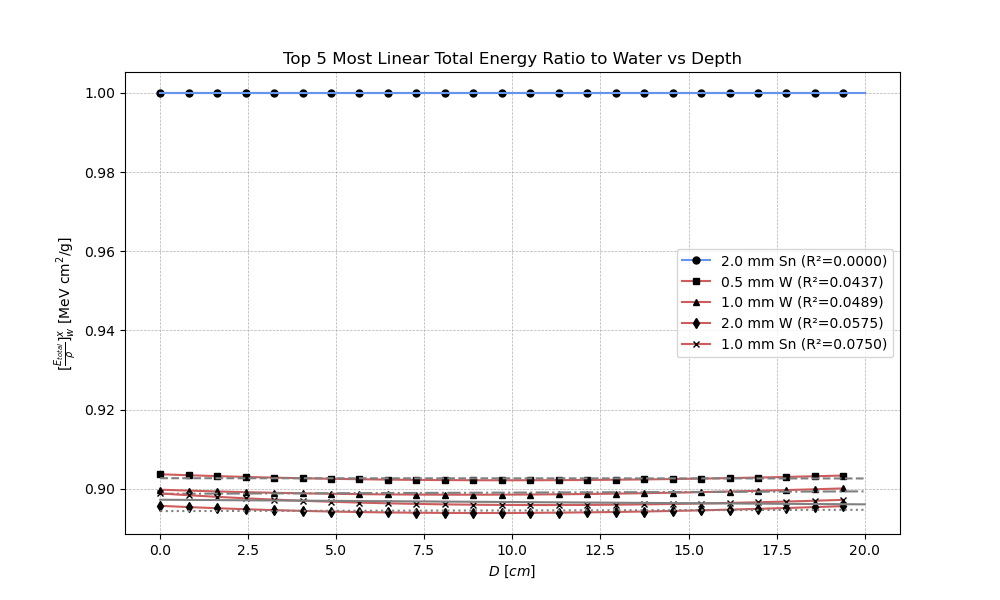

In [53]:
r_squared_values = []

for ii in range(total_energies.shape[1]):
    if ii == 9:
        y = total_energies[:, ii] / total_energies[:, 9]
    else:
        y = total_energies[:, ii] / total_energies[:, 9] / 2.33
    
    # Perform linear fit
    p = np.polyfit(depths, y, 1)
    y_fit = np.polyval(p, depths)
    
    # Calculate R-squared value
    r_squared = -np.std(y)
    r_squared_values.append((df['Subdirectory'].unique()[ii], r_squared, depths, y, y_fit))

# Sort by R-squared value to find the most linear curves
r_squared_values.sort(key=lambda x: x[1], reverse=True)

# Define line styles and markers for classic black and white plots
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'd', 'x']
labels = ['2.0 mm Sn',
            '0.5 mm W',
            '1.0 mm W',
            '2.0 mm W',
            '1.0 mm Sn']


# Plot only the top 5 most linear curves
plt.figure(figsize=(10, 6))
for i, (subdir, r_squared, depths, y, y_fit) in enumerate(r_squared_values[:5]):
    if i == 0:
        plt.plot(depths[::4], y[::4], label=f'{labels[i]} (R²={-100*r_squared:.4f})', marker=markers[i % len(markers)], color='cornflowerblue', markersize=5,markerfacecolor='k',markeredgecolor='k')
        plt.plot(depths, y_fit, linestyle=line_styles[i % len(line_styles)], color='cornflowerblue')
    else:
        plt.plot(depths[::4], y[::4], label=f'{labels[i]} (R²={-100*r_squared:.4f})', marker=markers[i % len(markers)], color='indianred', markersize=5,markerfacecolor='k',markeredgecolor='k')
        plt.plot(depths, y_fit, linestyle=line_styles[i % len(line_styles)], color='gray')

plt.xlabel('$D$ $[cm]$')
plt.ylabel(r"$[\frac{E_{total}}{\rho}]_w^x$ [MeV cm$^2$/g]")
plt.title('Top 5 Most Linear Total Energy Ratio to Water vs Depth')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# plt.show()

# Print the top 5 most linear curves
print("Top 5 most linear curves based on R-squared values:")
for subdir, r_squared, _, _, _ in r_squared_values[:5]:
    print(f"{subdir}: R-squared = {r_squared:.4f}")

# Top 5 most linear curves based on R-squared values:
# ./2.0mm_SnBU: R-squared = 0.9993
# ./0.5mm_WBU: R-squared = 0.9934
# ./1mm_WBU: R-squared = 0.9852
# ./2.0mm_WBU: R-squared = 0.9821
# ./1mm_SnBU: R-squared = 0.9805

Top 5 most linear curves based on R-squared values:
./0mm_Water: R-squared = -0.0000
./0.1mm_WBU: R-squared = -0.0004
./0.5mm_SnBU: R-squared = -0.0005
./1mm_CuBU: R-squared = -0.0006
./2.0mm_TiBU: R-squared = -0.0008


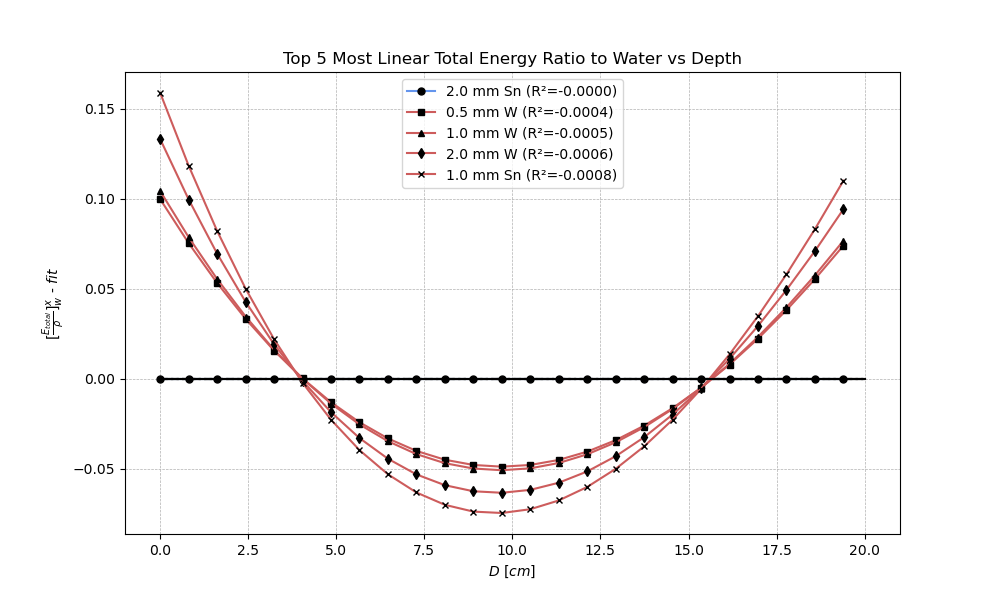

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Assuming total_energies and depths are already defined
# total_energies = ...
# depths = ...

# plt.figure()
r_squared_values = []

for ii in range(total_energies.shape[1]):
    if ii == 9:
        y = total_energies[:, ii] / total_energies[:, 9]
    else:
        y = total_energies[:, ii] / total_energies[:, 9] / 2.33
    
    # Perform linear fit
    p = np.polyfit(depths, y, 1)
    y_fit = np.polyval(p, depths)
    
    # Calculate R-squared value
    r_squared = -np.std(y)
    r_squared_values.append((df['Subdirectory'].unique()[ii], r_squared, depths, y, y_fit))

# Sort by R-squared value to find the most linear curves
r_squared_values.sort(key=lambda x: x[1], reverse=True)

# Define line styles and markers for classic black and white plots
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'd', 'x']
#./2.0mm_SnBU: R-squared = 0.9988
# ./0.5mm_WBU: R-squared = 0.9947
# ./1mm_WBU: R-squared = 0.9914
# ./2.0mm_WBU: R-squared = 0.9908
# ./1mm_SnBU: R-squared = 0.9854
labels = ['2.0 mm Sn',
            '0.5 mm W',
            '1.0 mm W',
            '2.0 mm W',
            '1.0 mm Sn']


# Plot only the top 5 most linear curves
plt.figure(figsize=(10, 6))
for i, (subdir, r_squared, depths, y, y_fit) in enumerate(r_squared_values[:5]):
    if i == 0:
        plt.plot(depths[::4], 100*(y[::4] - y_fit[::4]), label=f'{labels[i]} (R²={r_squared:.4f})', marker=markers[i % len(markers)], color='cornflowerblue', markersize=5,markerfacecolor='k',markeredgecolor='k')
        plt.plot(depths, y_fit - y_fit, linestyle=line_styles[i % len(line_styles)], color='black')
    else:
        plt.plot(depths[::4], 100*(y[::4] - y_fit[::4]), label=f'{labels[i]} (R²={r_squared:.4f})', marker=markers[i % len(markers)], color='indianred', markersize=5,markerfacecolor='k',markeredgecolor='k')
        plt.plot(depths, y_fit - y_fit, linestyle=line_styles[i % len(line_styles)], color='black')

plt.xlabel('$D$ $[cm]$')
plt.ylabel(r"$[\frac{E_{total}}{\rho}]_w^x$ - $fit$")
plt.title('Top 5 Most Linear Total Energy Ratio to Water vs Depth')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# plt.show()

# Print the top 5 most linear curves
print("Top 5 most linear curves based on R-squared values:")
for i, (subdir, r_squared, _, _, _) in enumerate(r_squared_values[:5]):
    print(f"{subdir}: R-squared = {r_squared:.4f}")
plt.legend()


In [ ]:
import gecco

In [72]:
mv_truebeam = gecco.Spectrum()
mv_truebeam.load('Varian_truebeam')

mv_tb_fff = gecco.Spectrum()
mv_tb_fff.load('Varian_truebeam_phasespace')
# mv_tb_fff.attenuate(0.1,mu = gecco.get_mu(74))

In [73]:
yy_tb_fff

array([8.83477034e-120, 8.47885127e-014, 1.40066094e-014, 9.33907406e-010,
       7.92110403e-008, 6.57615379e-007, 1.99350690e-006, 3.56363747e-006,
       5.01542572e-006, 6.19077490e-006, 6.94796699e-006, 7.40980432e-006,
       7.65863632e-006, 7.79256278e-006, 7.76897332e-006, 7.67922686e-006,
       9.09410153e-006, 7.29062724e-006, 7.09378777e-006, 6.90834381e-006,
       6.68777067e-006, 6.46445050e-006, 6.25045143e-006, 6.06030396e-006,
       5.88057197e-006, 5.69687902e-006, 5.52494534e-006, 5.35065779e-006,
       5.18904836e-006, 5.01571185e-006, 4.86048826e-006, 4.70328216e-006,
       4.55459364e-006, 4.42491185e-006, 4.30467039e-006, 4.16158515e-006,
       4.05043581e-006, 3.92503494e-006, 3.82198445e-006, 3.70462609e-006,
       3.60271390e-006, 3.50195495e-006, 3.40485002e-006, 3.29966914e-006,
       3.20438645e-006, 3.12331757e-006, 3.03726502e-006, 2.94739593e-006,
       2.86807521e-006, 2.79630752e-006, 2.72783283e-006, 2.64617891e-006,
       2.57499298e-006, 2

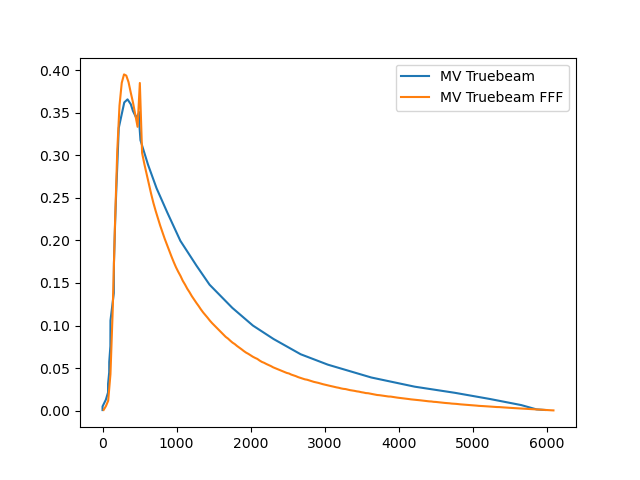

In [74]:
plt.figure()
xx_tb, yy_tb = mv_truebeam.x, mv_truebeam.y
xx_tb_fff, yy_tb_fff = mv_tb_fff.x, np.array(mv_tb_fff.y)

plt.plot(xx_tb, len(yy_tb)**0.5*yy_tb/(sum(yy_tb)), label='MV Truebeam')
plt.plot(xx_tb_fff, len(yy_tb_fff)**0.5*yy_tb_fff/(sum(yy_tb_fff)), label='MV Truebeam FFF')
plt.legend()

ValueError: Expect x to not have duplicates

In [100]:
df['Energy']

0        10.0
1        20.0
2        30.0
3        40.0
4        50.0
        ...  
319     900.0
320    1000.0
321    2000.0
322    4000.0
323    6000.0
Name: Energy, Length: 324, dtype: float64

In [ ]:
det = gecco.De

In [ ]:
thicknesses = [0.1,0.5,1,2]
materials = ['Cu','Ti','Sn','W']

command = []
command.append('mkdir')
for material in materials:
    for thickness in thicknesses:
        dir_name = f'{material}Si-{thickness}-784-micrometer'
        command.append(dir_name)
        
print(' '.join(command))    

mkdir CuSi-0.1-784-micrometer CuSi-0.5-784-micrometer CuSi-1-784-micrometer CuSi-2-784-micrometer TiSi-0.1-784-micrometer TiSi-0.5-784-micrometer TiSi-1-784-micrometer TiSi-2-784-micrometer SnSi-0.1-784-micrometer SnSi-0.5-784-micrometer SnSi-1-784-micrometer SnSi-2-784-micrometer WSi-0.1-784-micrometer WSi-0.5-784-micrometer WSi-1-784-micrometer WSi-2-784-micrometer


In [93]:
gecco.list_detectors()


AVAILABLE DETECTORS (for fc.detector(s,'DETECTOR')):

00mm_CuBU-784-micrometer
01mm_CuBU-784-micrometer
01mm_SnBU-784-micrometer
01mm_TiBU-784-micrometer
01mm_WBU-784-micrometer
05mm_CuBU-784-micrometer
05mm_SnBU-784-micrometer
05mm_TiBU-784-micrometer
05mm_WBU-784-micrometer
0mm_Water-784-micrometer
1mm_CuBU-784-micrometer
1mm_SnBU-784-micrometer
1mm_TiBU-784-micrometer
1mm_WBU-784-micrometer
20mm_CuBU-784-micrometer
20mm_SnBU-784-micrometer
20mm_TiBU-784-micrometer
20mm_WBU-784-micrometer
CWO-261-micrometer
CWO-392-micro_thin
CWO-392-micrometer
CWO-784-micrometer
CZT-330-micrometer
CZT-342-micrometer
CsI-010-micrometer
CsI-100-micrometer
CsI-150-micrometer
CsI-336-micrometer
CsI-392-micrometer
CsI-784-micro_thin
CsI-784-micrometer
CuGOS-336-micrometer
CuGOS-392-micrometer
CuGOS-784-micrometer


In [ ]:
detectors = [
    "00mm_CuBU-784-micrometer",
    "01mm_CuBU-784-micrometer",
    "01mm_SnBU-784-micrometer",
    "01mm_TiBU-784-micrometer",
    "01mm_WBU-784-micrometer",
    "05mm_CuBU-784-micrometer",
    "05mm_SnBU-784-micrometer",
    "05mm_TiBU-784-micrometer",
    "05mm_WBU-784-micrometer",
    "0mm_Water-784-micrometer",
    "1mm_CuBU-784-micrometer",
    "1mm_SnBU-784-micrometer",
    "1mm_TiBU-784-micrometer",
    "1mm_WBU-784-micrometer",
    "20mm_CuBU-784-micrometer",
    "20mm_SnBU-784-micrometer",
    "20mm_TiBU-784-micrometer",
    "20mm_WBU-784-micrometer",
    "CWO-261-micrometer",
    "CWO-392-micro_thin",
    "CWO-392-micrometer",
    "CWO-784-micrometer",
    "CZT-330-micrometer",
    "CZT-342-micrometer",
    "CsI-010-micrometer",
    "CsI-100-micrometer",
    "CsI-150-micrometer",
    "CsI-336-micrometer",
    "CsI-392-micrometer",
    "CsI-784-micro_thin",
    "CsI-784-micrometer",
    "CuGOS-336-micrometer",
    "CuGOS-392-micrometer",
    "CuGOS-784-micrometer"
]
for dets in detectors:
    det = gecco.detector.Detector(mv_tb_fff,det)
    det.weights

array([3.02015952e-02, 4.05569913e-02, 3.27824674e-02, 5.00314989e-02,
       1.16557156e-01, 1.76294366e-01, 1.91118008e-01, 1.60740489e-01,
       1.03590544e-01, 3.53542883e-02, 1.06350756e-02, 9.16498857e-03,
       7.64824789e-03, 6.22485685e-03, 4.84957930e-03, 3.56052142e-03,
       2.96059922e-03, 2.13626206e-03, 1.85994980e-03, 1.60800139e-03,
       1.36987154e-03, 1.14912589e-03, 9.45943329e-04, 8.09943578e-04,
       7.23138165e-04, 6.40983921e-04, 5.65090233e-04, 4.93704042e-04,
       4.27494717e-04, 3.64189521e-04, 3.26728804e-04, 2.91256580e-04,
       2.58169626e-04, 2.39344272e-04, 2.26257608e-04, 2.12436531e-04,
       2.00687644e-04, 1.88638521e-04, 1.78049317e-04, 1.67160084e-04,
       1.57326232e-04, 1.47904305e-04, 1.38960065e-04, 1.30010418e-04,
       1.21752987e-04, 1.14301194e-04, 1.06917231e-04, 9.96725670e-05,
       9.30195983e-05, 8.68432439e-05, 8.09918542e-05, 7.49615652e-05,
       6.94429836e-05, 6.41786778e-05, 5.89604823e-05, 5.44473819e-05,
      

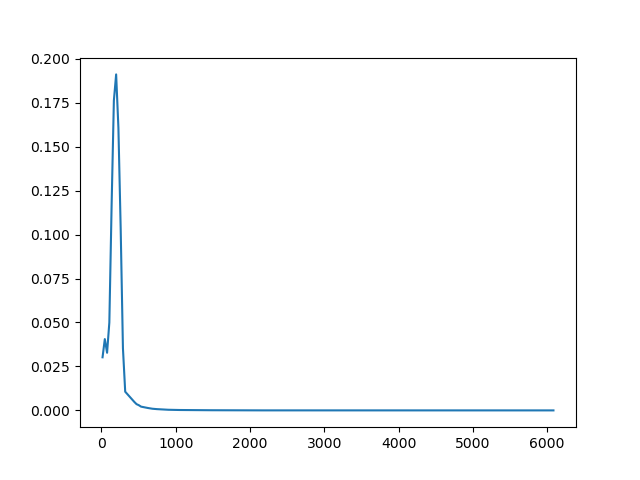

In [98]:
plt.figure()
plt.plot(mv_tb_fff.x, det.weights)

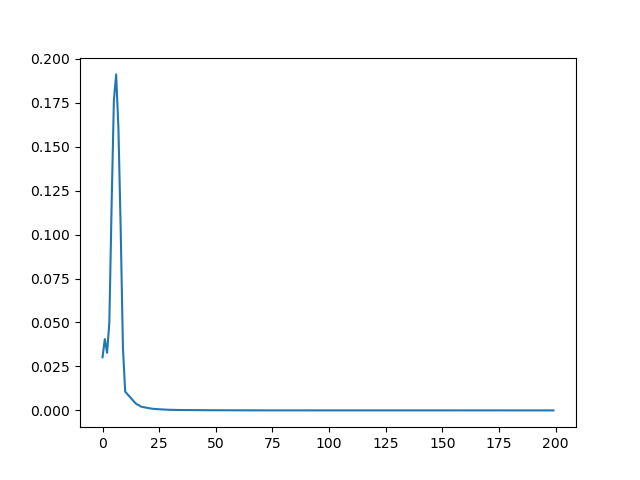

In [87]:
plt.figure()
plt.plot(det.weights)

In [79]:
gecco.detector.Detector?

Init signature: gecco.detector.Detector(spectrum, detector, specify_file=False, file=None)
Docstring:      The Detector class is used to calculate the Modulation Transfer Function (MTF) for a given energy spectrum and detector.
Init docstring:
Initialize a Fastcat Detector object.

The spectrum is used to calculate the MTF (Modulation Transfer Function) for the detector.

Parameters
----------
spectrum : Fastcat Spectrum Object
    An energy spectrum of a beam for which the MTF is calculated.
detector : str
    The name of the detector. Should be one of the detector folders in data/Detectors.
    Example: 'CSI-784-micrometer' (where numbers are the pixel pitch).
specify_file : bool, optional
    Flag indicating whether to specify a custom file for deposition efficiency.
    Default is False.
file : str, optional
    Custom file path for deposition efficiency. Only used if `specify_file` is True.
    Default is None.

Returns
-------
Fastcat Detector object

Notes
-----
The `spectrum` o

Text(0.5, 1.0, 'Cu-GOS')

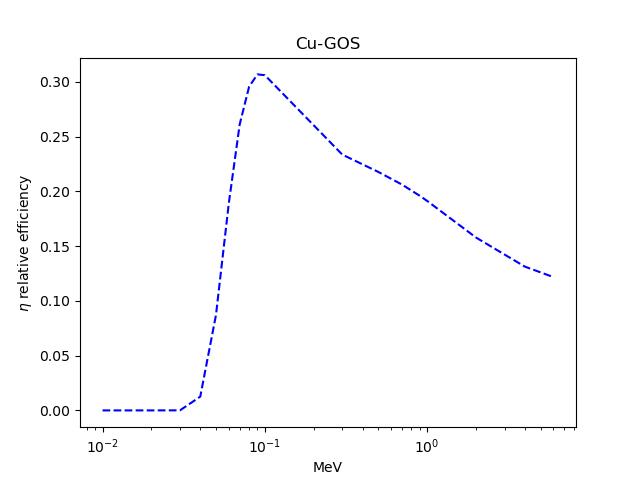

In [8]:
plt.figure()
plt.semilogx(energies/1000,deposition/(energies/1000)/10000000,'b--')
plt.xlabel('MeV')                                                       
plt.ylabel('$\eta$ relative efficiency')
# plt.savefig(f'analysis/{dt_string}/EnergyDeposition.png')
plt.title('Cu-GOS')

<IPython.core.display.Javascript object>


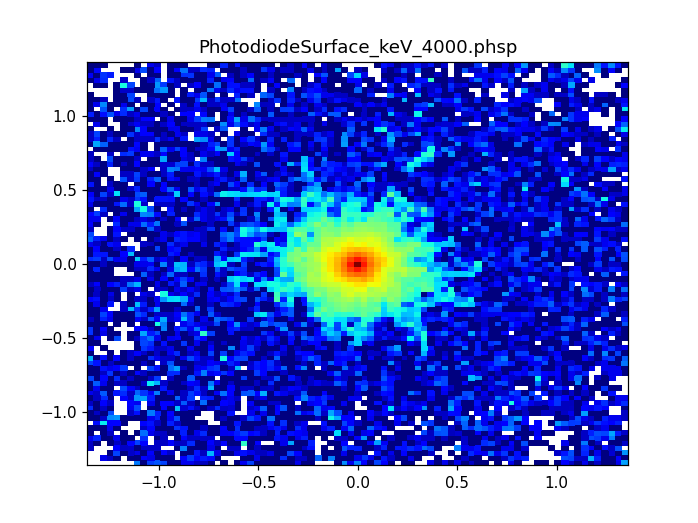

In [28]:
rootdir = "."
regex = re.compile('(.*.phsp$)|(.*rar$)|(.*r01$)')

phase_spaces = []
plt.figure()

# xedges = np.linspace(-1.5876+0.0196,1.5876-0.0196,40) # Changed from 82 JO 2020 07
# yedges = np.linspace(-1.5876+0.0196,1.5876-0.0196,40) # Changed from 40 JO 08


# edges_forward = (np.arange(0.0392,81*0.0782,0.0782))

# edges_forward = (np.arange(0.0196,41*0.0392,0.0392))

edges_forward = (np.arange(0.0168,41*0.0336,0.0336))

# edges_forward = (np.arange(0.001,151*0.002,0.002))

edges = np.hstack([-1*edges_forward[-1::-1], edges_forward])

xedges = edges #np.linspace(-2,2,201) # Changed from 82 JO 2020 07
yedges = edges #np.linspace(-2,2,201) # Changed from 40 JO 08

for root, dirs, files in os.walk(rootdir):
    for file in files:
        if regex.match(file):
            
            y = read_ntuple(os.path.join(rootdir,file))
#             xx = [y[kk][0] for kk in range(y.size)]
#             yy = [y[kk][1] for kk in range(y.size)]
            
            h,xs,yx,ima = plt.hist2d(y['Local position X [cm]'],y['Local position Y [cm]'], bins = [xedges,yedges], cmap=cm.jet, norm=LogNorm())
            plt.title(f'{file}')
            plt.savefig(f'analysis/{dt_string}/{file}.png')
            
            np.save(f'analysis/{dt_string}/{file}',h)


In [23]:
# lsf2 = h[40,:]
lsf = h[150,:]

<IPython.core.display.Javascript object>


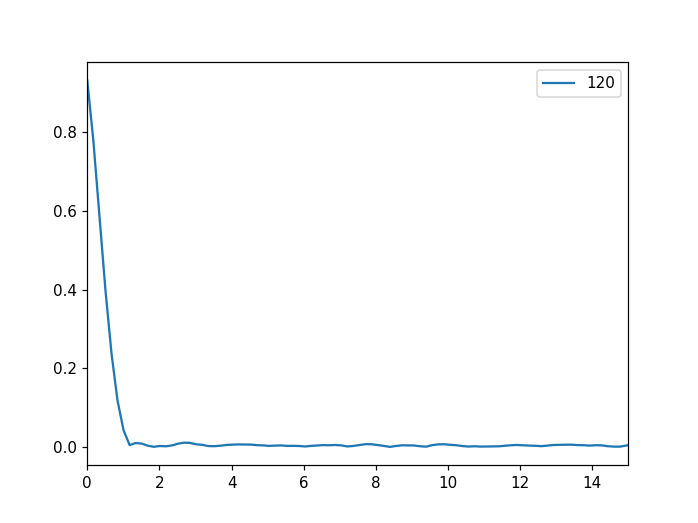

(0.0, 15.0)

In [24]:
# mtf = np.absolute(np.fft.fft(np.convolve(lsf,[0.2]*5)))
# mtf_final = np.fft.fftshift(mtf)

# N = len(mtf)

# T = 0.01

# xf = np.linspace(0.0, 1.0/(2.0*T), int(N/2))

# mm = np.argmax(mtf_final)
# plt.figure()
# plt.plot(mtf_final[mm:]/mtf_final[mm])

mtf = np.absolute(np.fft.fft(lsf))
mtf_final = np.fft.fftshift(mtf)

N = len(mtf)

T = 0.02

xf = np.linspace(0.0, 1.0/(2.0*T), int(N/2))

mm = np.argmax(mtf_final)

plt.figure()
plt.plot(xf,mtf_final[mm+1:]/mtf_final[mm])
plt.legend(['120','6000'])
plt.xlim([0,15])

# mtf = np.absolute(np.fft.fft(lsf2))
# mtf_final = np.fft.fftshift(mtf)

# N = len(mtf)

# T = 0.0336

# xf = np.linspace(0.0, 1.0/(2.0*T), int(N/2))

# mm = np.argmax(mtf_final)

# # plt.figure()
# plt.plot(xf,mtf_final[mm+1:]/mtf_final[mm])
# plt.legend(['120','6000'])
# plt.xlim([0,15])

In [49]:
len(xf[:mm+1])

150

In [51]:
len(xf)

150

<IPython.core.display.Javascript object>


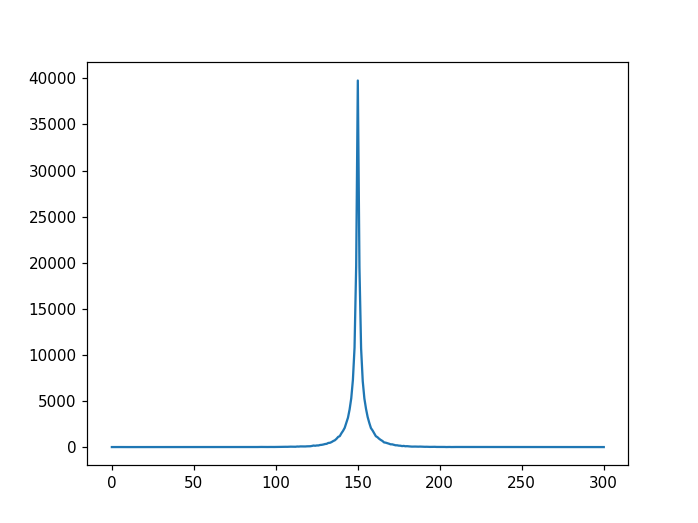

In [67]:
plt.figure()
plt.plot(h[150,:])
# plt.plot(h[41,:])
# plt.plot(h[42,:])

In [ ]:
from PIL import Image
import glob

# Create the frames
frames = []
imgs = sorted(glob.glob("analysis/2020-06-03-h14m33/*.png"))

for i in imgs:
    new_frame = Image.open(i)
    frames.append(new_frame)

# Save into a GIF file that loops forever
frames[0].save('png_to_gif.gif', format='GIF',
               append_images=frames[1:],
               save_all=True,
               duration=300, loop=0)

In [10]:
!cat ~/anaconda3/lib/python3.7/site-packages/topas2numpy/ntuple.py

# -*- coding: utf-8 -*-

# system imports
import re
import os.path

# third-party imports
import numpy as np

re_uint = '\d+'
re_str = '[\S+ \t]+'

binary_old_int_columns = [
    'Particle Type (in PDG Format)',
    'Run ID',
    'Event ID',
    'Track ID',
    'Parent ID',
    'Seed Part 1',
    'Seed Part 2',
    'Seed Part 3',
    'Seed Part 4',
]

limited_col_names = [
    ('Particle Type (sign from z direction)', np.int8),
    ('Energy (MeV) (-ve if new history)', 'f'),
    ('Position X (cm)', 'f'),
    ('Position Y (cm)', 'f'),
    ('Position Z (cm)', 'f'),
    ('Direction Cosine X', 'f'),
    ('Direction Cosine Y', 'f'),
    ('Weight', 'f'),
]


def read_ntuple(filepath):
    root, ext = os.path.splitext(filepath)
    ntuple_path = root + '.phsp'
    header_path = root + '.header'

    file_format, col_names = _sniff_format(header_path)

    if file_format == 'ascii':
        # preserve column names => cannot be viewed as a np.recarray
        # http://docs.scipy.org/doc/numpy-1

In [11]:
file

'PhotodiodeSurface_keV_6000.phsp'

In [12]:
!pwd

/home/xcite/topas/scintillators/Cu-GOS/runs


In [13]:
68372568/2848857

24.0

In [14]:
150398688/6266612

24.0

In [15]:
7437024/24

309876.0

In [36]:
xedges = np.linspace(-1.5876+0.0196,1.5876-0.0196,41)

(max(xedges) - min(xedges))/40

0.0784

In [34]:
0.25*0.784

0.196